In [1]:
from clu import checkpoint

from tqdm import trange

import jax, flax
import numpy as np
import jax.numpy as jnp
import jax.random as jr

import transformer
from transformer import HollowTransformer

from matplotlib import pyplot as plt

key = jr.PRNGKey(0)

2025-01-10 04:34:54.792759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-10 04:34:55.384585: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-10 04:34:55.614030: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-10 04:35:02.923907: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Configs

In [9]:
import ml_collections

class AbsorbingRate():
  def __init__(self, config):
    self.state_size = S = config.state_size
    self.scalar_rate = 1
    self.eps = config.rate_eps
    
    mask = S-1

    rate = np.zeros((S, S))
    rate[:-1, -1] = self.scalar_rate
    rate -= np.diag(jnp.sum(rate, axis=1))
    self.eigvals, self.eigvecs = jnp.linalg.eigh(rate)
    self.eigvals, self.eigvecs = np.linalg.eig(rate)
    self.inv_eigvecs = np.linalg.inv(self.eigvecs)
        
    self.base_rate = jnp.array(rate, dtype=np.float32)
#       self.rate_matrix = self.base_rate
    self.eigvals = jnp.array(self.eigvals, dtype=np.float32)
    self.eigvecs = jnp.array(self.eigvecs, dtype=np.float32)
    self.inv_eigvecs = jnp.array(self.inv_eigvecs, dtype=np.float32)
        
  def target_logits(self):
    S = self.state_size
    logits = - jnp.ones((S,)) * 10000
    return logits.at[-1].set(0)
      
  def _integral_rate_scalar(self, t):
    return -jnp.log1p(-(1 - self.eps) * t)
  
  def _rate_scalar(self, t):
    return (1 - self.eps) / (1 - (1 - self.eps) * t)
      
  def rate(self, t):
    return self._rate_scalar(t) * self.base_rate

  def transition(self, t, t0 = 0):
    S = self.state_size
    integral_rate_scalar = self._integral_rate_scalar(t+t0) - self._integral_rate_scalar(t0)
    adj_eigvals = integral_rate_scalar * self.eigvals
    trans = jnp.einsum("ij,jk,kl->il", self.eigvecs, jnp.diag(jnp.exp(adj_eigvals)), self.inv_eigvecs, 
                       precision=jax.lax.Precision.HIGHEST)
    trans = jnp.clip(trans, 0., 1.)
    return trans

  def survival_prob(self, t):
    """
    Returns fraction of tokens not masked at time t in expectation
    """
    # Return the (0,0) entry in the transition probability matrix
    return self.transition(t)[0, 0]

class AbsorbingRateCosine():
  def __init__(self, config):
    self.state_size = S = config.state_size
    self.scalar_rate = 1
    self.eps = config.rate_eps
    
    mask = S-1

    rate = np.zeros((S, S))
    rate[:-1, -1] = self.scalar_rate
    rate -= np.diag(jnp.sum(rate, axis=1))
    self.eigvals, self.eigvecs = jnp.linalg.eigh(rate)
    self.eigvals, self.eigvecs = np.linalg.eig(rate)
    self.inv_eigvecs = np.linalg.inv(self.eigvecs)
        
    self.base_rate = jnp.array(rate, dtype=np.float32)
#       self.rate_matrix = self.base_rate
    self.eigvals = jnp.array(self.eigvals, dtype=np.float32)
    self.eigvecs = jnp.array(self.eigvecs, dtype=np.float32)
    self.inv_eigvecs = jnp.array(self.inv_eigvecs, dtype=np.float32)
        
  def target_logits(self):
    S = self.state_size
    logits = - jnp.ones((S,)) * 10000
    return logits.at[-1].set(0)
          
  def mask_percentage(self, t):
    return 1 - self.alpha(t)

  def alpha(self, t):
    """
    Survival probability of a token at time t
    """
    b = 1 - self.eps
    theta = jnp.pi / 2 * (1 - t * b)
    return 1 - jnp.cos(theta)

  def dalpha(self, t):
    """
    Time derivative of alpha_t (the survival probability of a token at time t)
    """
    b = 1 - self.eps
    theta = jnp.pi / 2 * (1 - t * b)
    return - b * jnp.pi / 2 * jnp.sin(theta)

  def _integral_rate_scalar(self, t):
    # This is -log of (1-m(t)) where m(t) is the desired mask percentage at time t.
    return - jnp.log(self.alpha(t))

  def _rate_scalar(self, t):
    return - self.dalpha(t) / self.alpha(t)
      
  def rate(self, t):
    return self._rate_scalar(t) * self.base_rate

  def transition(self, t, t0 = 0):
    S = self.state_size
    integral_rate_scalar = self._integral_rate_scalar(t+t0) - self._integral_rate_scalar(t0)
    adj_eigvals = integral_rate_scalar * self.eigvals
    trans = jnp.einsum("ij,jk,kl->il", self.eigvecs, jnp.diag(jnp.exp(adj_eigvals)), self.inv_eigvecs, 
                       precision=jax.lax.Precision.HIGHEST)
    trans = jnp.clip(trans, 0., 1.)
    return trans

def d(**kwargs):
  """Helper of creating a config dict."""
  return ml_collections.ConfigDict(initial_dictionary=kwargs)


def get_config():
  """Get the hyperparameters for the model"""
  config = ml_collections.ConfigDict()
  config.exp_name = "exp_vdm"
  config.model_type = "model_transformer"
  # config.ckpt_restore_dir = 'None'
  config.ckpt_restore_dir = 'gs://maskdiff/hollow/241011/checkpoints-0'

  config.use_hollow_transformer = True

  config.data = d(
      dataset='tokenized_imagenet_256',  # cifar10/cifar10_aug/cifar10_aug_with_channel
      ignore_cache=False,
      seq_length=256,
      codebook_size=1024,
  )

  config.model = d(
    # tpu-v3 has less memory, use smaller network?
    vocab_size=1024 + 1, # Caveat: conditional generation stuff
    hidden_size=768 // 2,
    num_hidden_layers=24, # 24
    num_attention_heads=16 // 2,
    intermediate_size=3072 // 3 * 2,
    hidden_dropout_prob=0.1, 
    attention_probs_dropout_prob=0.1, # Same as hidden dropout prob
    max_position_embeddings=256, # seq length, since we are doing unconditional generation
    num_layers_per_mixed=6,

    # time conditioning
    # time_embedding_size=64,
    # time_scale_factor=1000,
    # mask_token_id = -1,
  )

  config.sampler = d(
    seed=42,
    num_steps=10, 
    max_samples=10_000,
    output_file_name="fb_samples_10k",
    corrector="forward_backward",
    corrector_step_size=1.,
  )

  config.noise = d(
    state_size=1024 + 1,
    rate_eps=1e-3
  )

  config.training = d(

      min_t=0.01,
      max_t=1.,
      eps=1e-6,
      nll_weight=.01,

      seed=1,
      substeps=1,
      num_steps_lr_warmup=100,
      num_steps_train=500_000, #100_000_000,
      num_steps_eval=100,
      batch_size_train=768 * 2, #1024 in paper version
      batch_size_eval=1024,
      steps_per_logging=100,
      steps_per_eval=1_000,
      steps_per_save=10_000,
      profile=False,
  )

  config.optimizer = d(
      name='adamw',
      args=d(
          b1=0.9,
          b2=0.99,
          eps=1e-8,
          weight_decay=0.01,
      ),
      learning_rate=1e-4, #2e-4 in paper version
      lr_decay=False,
      ema_rate=0.9999,
  )

  config.vqvae = ml_collections.ConfigDict()
  config.vqvae.quantizer = "vq"
  config.vqvae.codebook_size = 1024

  config.vqvae.entropy_loss_ratio = 0.1
  config.vqvae.entropy_temperature = 0.01
  config.vqvae.entropy_loss_type = "softmax"
  config.vqvae.commitment_cost = 0.25

  config.vqvae.filters = 128
  config.vqvae.num_res_blocks = 2
  config.vqvae.channel_multipliers = [1, 1, 2, 2, 4]
  config.vqvae.embedding_dim = 256
  config.vqvae.conv_downsample = False
  config.vqvae.activation_fn = "swish"
  config.vqvae.norm_type = "GN"

  return config

In [10]:
# Visualizing cosine rates
noise_config = d(
    state_size=1024 + 1,
    rate_eps=1e-3
  )

forward_process = AbsorbingRateCosine(noise_config)

[ 3 11 18 25 31 36 40 43 44]


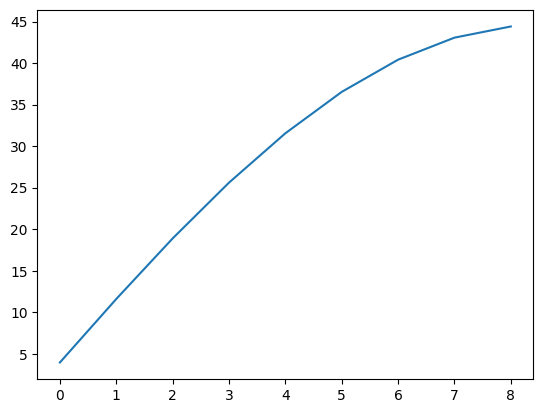

In [11]:
ts = jnp.linspace(1., 0., 10)
ms = forward_process.mask_percentage(ts)
mask_counts = ms * 256
unmasked_count = mask_counts[:-1] - mask_counts[1:]
print(unmasked_count.astype(int))
plt.plot(unmasked_count)

[ 4 14 23 31 38 44 47 49]


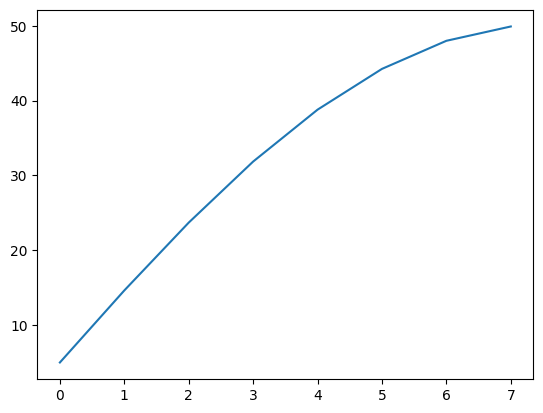

In [14]:
# Visualize how many tokens are unmasked at each time step
ts = jnp.linspace(1., 0., 9)
ms = forward_process.mask_percentage(ts)
mask_counts = ms * 256
unmasked_count = mask_counts[:-1] - mask_counts[1:]
print(unmasked_count.astype(int))
plt.plot(unmasked_count)

## Loading checkpoint

In [3]:
checkpoint_dir = 'gs://maskdiff/cond_hollow/241011/checkpoints-0'

ckpt = checkpoint.Checkpoint(checkpoint_dir)
state_dict = ckpt.restore_dict()
params = flax.core.FrozenDict(state_dict['ema_params'])
step = int(state_dict['step'])

In [84]:
config = get_config()
forward_process = AbsorbingRate(config.noise)
seq_len = config.model.max_position_embeddings
vocab_size = config.model.vocab_size
model = transformer.HollowTransformer(**config.model)

In [5]:
# l = 5

# key, _ = jr.split(key)
# inputs = jr.categorical(logits=jnp.ones((vocab_size,)), shape=(1, seq_len), key=key)
# out1 = model.apply({"params": params}, inputs, None, deterministic=True)
# # Shift the token on the lth position
# inputs = inputs.at[0, l].set((inputs[0, l] - 1) % vocab_size)
# out2 = model.apply({"params": params}, inputs, None, True)
# # Should be zeros!
# print((out1 - out2)[0, l])

## Conditional sampling

In [112]:
import jax
from jax import numpy as jnp
from jax.nn import softmax
import jax.random as jr
from tqdm import trange
from functools import partial

def euler_update(key, x, rates):
    D = x.shape[0]
    eps = 1e-8
    # Mask out the self transitions
    rates = rates.at[jnp.arange(D), x].set(0.0)
    sum_rates = jnp.sum(rates, axis=1)
    # transition_logit = jnp.log(-jnp.expm1(-rates)) # Prob = 1 - exp(-rate)
    transition_logit = jnp.log(-jnp.expm1(-sum_rates))[:,None] + jnp.log(rates) - jnp.log(sum_rates + eps)[:,None]
    transition_logit = transition_logit.at[jnp.arange(D), x].set(-sum_rates)
    
    out = jr.categorical(key, transition_logit).astype(jnp.int32)
    return out

def compute_backward(y_with_label, t, apply_fn, params, config, forward_process):
    y_with_label = y_with_label.flatten()
    y = y_with_label[1:-1]

    D = y.shape[0]
    S = config.data.codebook_size + 1
    mask = -1
    # forward_process = config.forward_process
    min_t = config.training.min_t
    eps = config.training.eps
    qt0 = forward_process.transition(t)
    # R^d_t(*1,*2): (S, S) float array of instantenous transition rates
    # for a single dimension
    Rt = forward_process.rate(t)
    Rt_eval_y = Rt[:, y].T
    
    # Set corresponding values to mask 
    y_with_label = jnp.where((y_with_label == (S-1)), mask, y_with_label)
    x0_logits = apply_fn({"params": params}, y_with_label[None], t, 
        deterministic=True)
    # Only take the valid parts of the output
    x0_logits = x0_logits[0,1:-1,:S]

    # Set mask logits to minus infinity and normalize
    x0_logits = x0_logits.at[:, mask].set(-jnp.inf)
    x0_logits -= jax.scipy.special.logsumexp(x0_logits, axis=-1, 
        keepdims=True)
    
    # p^{*1}_{0|t}(*2|y): (D, S) float array of marginal likelihoods for each dimension predicted by the model
    p0t_eval_y = softmax(x0_logits, axis=-1)
    
    # q^{*1}_{t|0}(y^d|*2): (D, S) float array of transition probabilities to y
    # However, now each dimension is assumed to be a mask token
    # This is the change that fixes everything!
    qt0_eval_y = qt0[:,mask][None] + eps
    # qt0_eval_y = qt0[:,y].T + eps

    st_eval_y = jnp.einsum("0x,d0->dx", qt0, p0t_eval_y / qt0_eval_y, 
                           precision=jax.lax.Precision.HIGHEST)

    # Since every dimension considers itself as the mask, we set the ratio to 1
    st_eval_y = st_eval_y.at[:, mask].set(1.0)
    backward_score_to_curr = st_eval_y[jnp.arange(D), y] #+ eps
    # On mask dimensions this is dividing by 1, on non-mask it offsets the score function to be centered on y
    st_eval_y /= backward_score_to_curr[:,None]

    # (D, S) float array that masks out y[d] for each d index
    y_mask = jnp.ones((D, S))
    y_mask = y_mask.at[jnp.arange(D), y].set(0.0)

    # log score is easier to compute
    alpha = forward_process.survival_prob(t)
    log_score = x0_logits + jnp.log(alpha) - jnp.log(1-alpha)
    log_score = log_score.at[:, mask].set(0)
    log_score = log_score - log_score[jnp.arange(D), y][:, None]
    
    results = {
        "score": st_eval_y,
        "log_score": log_score,
        "rates": (st_eval_y * Rt_eval_y) * y_mask,
        "x0_logits": x0_logits,
        "Rt_eval_y": Rt_eval_y,
        "Rt_eval_x": Rt[y],
        "rate_scalar": forward_process._rate_scalar(t)
    }
    return results
    
def backward_process_no_corrector(apply_fn, params, ts, config, xT, key, forward_process):

    t = ts[0]
    x = xT
    
    if config.sampler.update_type == "euler":
        update_func = euler_update
    elif config.sampler.update_type == "tau_leaping": 
        update_func = poisson_jump_reject
    else:
        raise Exception(f"Unknown update type: {config.sampler.update_type}")

    def _step(carry, idx):
        x, key = carry
        p_key, key = jr.split(key)
        t = ts[idx]
        dt = t - ts[idx+1]

        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]
        x = x.at[1:-1].set(update_func(key, x[1:-1], rp * dt))

        return (x, key), x

    (x, _), x_hist = jax.lax.scan(_step, (xT, key), jnp.arange(len(ts)-1))
    res = compute_backward(x, t, apply_fn, params, config, forward_process)
    x0_logits = res["x0_logits"]

    x0_pred = jnp.argmax(x0_logits, axis=1)

    return x0_pred, x_hist

def backward_process_gibbs_corrector(apply_fn, params, ts, config, xT, key, forward_process):

    S = config.data.codebook_size + 1
    D = config.data.seq_length
    mask = S - 1
    k = config.sampler.k
    t = ts[0]
    x = xT
    
    if config.sampler.update_type == "euler":
        update_func = euler_update
    elif config.sampler.update_type == "tau_leaping": 
        update_func = poisson_jump_reject
    else:
        raise Exception(f"Unknown update type: {config.sampler.update_type}")

    def _step(carry, idx):
        x, key = carry
        p_key, c_key, key = jr.split(key, 3)
        t = ts[idx]
        dt = t - ts[idx+1]

        # Predictor
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]
        x = x.at[1:-1].set(update_func(p_key, x[1:-1], rp * dt))

        # Corrector
        res = compute_backward(x, t-dt, apply_fn, params, config, forward_process)
        logits = res["x0_logits"].at[:, mask].set(-jnp.inf)
        # Sample a bunch of new values according to denoising model
        corrected = jr.categorical(c_key, logits).astype(jnp.int32)
        # Figure out locations with the lowest score
        # Since the score is proportional to the denoising prob anyways, we're just gonna use the logits again
        scores = res["x0_logits"][jnp.arange(D), x[1:-1]].T
        scores = jnp.where(x[1:-1] == mask, jnp.inf, scores)
        # Trick: sort and then find the kth smallest
        thres = jnp.sort(scores, axis=-1)[k-1]
        x = x.at[1:-1].set(jnp.where((scores <= thres) & (x[1:-1] != mask), corrected, x[1:-1]))
        
        return (x, key), x

    (x, _), x_hist = jax.lax.scan(_step, (xT, key), jnp.arange(len(ts)-1))
    res = compute_backward(x, t, apply_fn, params, config, forward_process)
    x0_logits = res["x0_logits"]

    x0_pred = jnp.argmax(x0_logits, axis=1)

    return x0_pred, x_hist

In [117]:
# Try to test correctness of log corrector
key, _ = jr.split(key)
label = 0

config = get_config()
forward_process = AbsorbingRate(config.noise)
config.model = d(
    vocab_size=1024 + 1000 + 1, # 1024 tokens, 1000 labels, 1 mask
    hidden_size=768,
    num_hidden_layers=24, # 24
    num_attention_heads=16,
    intermediate_size=3072 // 3,
    hidden_dropout_prob=0.1, 
    attention_probs_dropout_prob=0.1, # Same as hidden dropout prob
    max_position_embeddings=256 + 2, # label at start and end of sequence (because of the 2 streams)
    num_layers_per_mixed=24,
  )

seq_len = config.model.max_position_embeddings
vocab_size = config.model.vocab_size
model = transformer.HollowTransformer(**config.model)

S = config.data.codebook_size + 1
D = config.data.seq_length
min_t = config.training.min_t
max_t = config.training.max_t
config.sampler.num_steps = 16

config.sampler.k = 2

config.sampler.update_type = "euler"

sample_func = backward_process_gibbs_corrector

# Initialize the all-mask state
xT = jnp.ones((D,), dtype=int) * (S - 1)
xT = xT.at[0].set(0)
label_arr = jnp.array([label + S], dtype=jnp.int32)
xT_with_label = jnp.concatenate([label_arr, xT, label_arr])
res = compute_backward(xT_with_label, .6, model.apply, params, config, forward_process)

In [106]:
# old_res = res
# forward_process = AbsorbingRateCosine(config.noise)
forward_process = AbsorbingRate(config.noise)

offset = jnp.log(forward_process.transition(1)[0,0])
print(offset)

-6.9077625


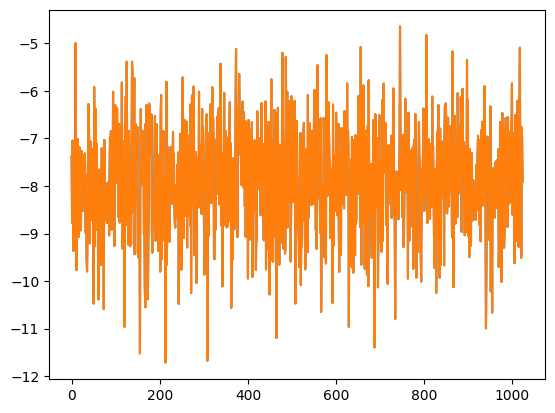

In [119]:
id = 1
plt.plot(res["log_score"][id,:-1])
plt.plot(jnp.log(res["score"])[id,:-1])
# plt.plot(jnp.log(old_res["score"])[0,:-1])

In [13]:
res["score"] - jnp.exp(res["log_score"])


Array([[-3.7144980e-04, -1.6931647e-02, -2.2984990e-03, ...,
        -6.9328353e-02, -9.2770229e-04, -9.5367432e-07],
       [-2.7740042e-04, -6.0913227e-03, -1.6915586e-02, ...,
        -1.0961189e-02, -1.0257078e-02, -9.5367432e-07],
       [-6.9014577e-04, -7.1745962e-03, -9.8734936e-03, ...,
        -1.0077475e-02, -7.0671821e-03, -9.5367432e-07],
       ...,
       [-9.1885598e-03, -2.4057442e-02, -2.8020786e-02, ...,
        -4.0646708e-03, -9.3767289e-03, -9.5367432e-07],
       [-7.4855261e-03, -1.7080709e-02, -1.9217221e-02, ...,
        -1.5837556e-03, -7.4060992e-03, -9.5367432e-07],
       [-7.1965195e-03, -5.5752979e-03, -1.5458943e-02, ...,
        -4.4604717e-04, -6.8061650e-03, -9.5367432e-07]], dtype=float32)

In [60]:
key, _ = jr.split(key)
label = 0

config = get_config()
forward_process = AbsorbingRate(config.noise)
config.model = d(
    vocab_size=1024 + 1000 + 1, # 1024 tokens, 1000 labels, 1 mask
    hidden_size=768,
    num_hidden_layers=24, # 24
    num_attention_heads=16,
    intermediate_size=3072 // 3,
    hidden_dropout_prob=0.1, 
    attention_probs_dropout_prob=0.1, # Same as hidden dropout prob
    max_position_embeddings=256 + 2, # label at start and end of sequence (because of the 2 streams)
    num_layers_per_mixed=24,
  )

seq_len = config.model.max_position_embeddings
vocab_size = config.model.vocab_size
model = transformer.HollowTransformer(**config.model)

S = config.data.codebook_size + 1
D = config.data.seq_length
min_t = config.training.min_t
max_t = config.training.max_t
config.sampler.num_steps = 16

config.sampler.k = 2

config.sampler.update_type = "euler"

sample_func = backward_process_gibbs_corrector

# Initialize the all-mask state
xT = jnp.ones((D,), dtype=int) * (S - 1)
label_arr = jnp.array([label + S], dtype=jnp.int32)
xT_with_label = jnp.concatenate([label_arr, xT, label_arr])

ts = jnp.linspace(max_t, min_t, config.sampler.num_steps)

p_sample_func = jax.pmap(partial(sample_func, apply_fn=model.apply, params=params, ts=ts, config=config, xT=xT_with_label, 
                                 forward_process=forward_process))

tokens, hist = p_sample_func(key=jr.split(key, 8))

## Sampling code

## Note: right now we're replacing model outputs with constant values for debugging the correctors

In [385]:
from jax.nn import softmax
from functools import partial

# TODO: we're using the non-batched version of the sampling code to test what the model has learned

def poisson_jump_reject(key, x, rates):
    D = x.shape[0]
    # S = rates.shape[1]
    # Mask out the self transitions
    rates = rates.at[jnp.arange(D), x].set(0.0)
    # (D, S)
    jump_nums = jr.poisson(key, rates)
    jump_target = jnp.argmax(jump_nums, axis=1)

    out = jnp.where((jnp.sum(jump_nums, axis=1) == 1), jump_target, x)
    return out

def poisson_jump_accept(key, x, rates):
    D = x.shape[0]
    # S = rates.shape[1]
    # Mask out the self transitions
    rates = rates.at[jnp.arange(D), x].set(0.0)
    # (D, S)
    jump_nums = jr.poisson(key, rates)
    jump_target = jnp.argmax(jump_nums, axis=1)

    out = jnp.where((jnp.sum(jump_nums, axis=1) >= 1), jump_target, x)
    return out

def euler_update(key, x, rates):
    eps = 1e-8
    D = x.shape[0]
    # Mask out the self transitions
    rates = rates.at[jnp.arange(D), x].set(0.0)
    sum_rates = jnp.sum(rates, axis=1)
    transition_logit = jnp.log(-jnp.expm1(-sum_rates))[:,None] + jnp.log(rates + eps) - jnp.log(sum_rates + eps)[:,None]
    transition_logit = transition_logit.at[jnp.arange(D), x].set(-sum_rates)
    
    out = jr.categorical(key, transition_logit).astype(jnp.int32)
    return out

def dumb_euler_update(key, x, rates):
    D = x.shape[0]
    # Mask out the self transitions
    rates = rates.at[jnp.arange(D), x].set(0.0)
    sum_rates = jnp.sum(rates, axis=1)
    rates = rates.at[jnp.arange(D), x].set(1 - sum_rates)
    rates = jnp.clip(rates, 0., 1.)
    
    out = jr.categorical(key, jnp.log(rates)).astype(jnp.int32)
    return out
    
def compute_backward(y, t, apply_fn, params, config, forward_process):
    y = y.flatten()
    D = y.shape[0]
    S = config.model.vocab_size

    mask = -1
    
    # forward_process = config.forward_process
    min_t = config.training.min_t
    eps = config.training.eps
    qt0 = forward_process.transition(t)
    # R^d_t(*1,*2): (S, S) float array of instantenous transition rates
    # for a single dimension
    Rt = forward_process.rate(t)
    Rt_eval_y = Rt[:, y].T
    
    x0_logits = apply_fn({"params": params}, y[None], t, 
        deterministic=True).squeeze()
    # # Only take the valid parts of the output
    # x0_logits = x0_logits[...,:S-1]

    # lol
    # x0_logits = jnp.ones((D, S))
    # x0_logits = x0_logits.at[:,-1].set(-jnp.inf)
    
    # p^{*1}_{0|t}(*2|y): (D, S) float array of marginal likelihoods for each dimension predicted by the model
    p0t_eval_y = softmax(x0_logits, axis=-1)


    # This might be the change that fixes everything.
    # Unfortunately things still don't quite work yet.
    qt0_eval_y = qt0[:,mask][None] + eps 

    st_eval_y = jnp.einsum("0x,d0->dx", qt0, p0t_eval_y / qt0_eval_y, 
                           precision=jax.lax.Precision.HIGHEST)

    # Since every dimension considers itself as the mask, we set the ratio to 1
    st_eval_y = st_eval_y.at[:, mask].set(1.0)
    backward_score_to_curr = st_eval_y[jnp.arange(D), y]
    # On mask dimensions this is dividing by 1, on non-mask it offsets the score function to be centered on y
    st_eval_y /= backward_score_to_curr[:,None]

    # (D, S) float array that masks out y[d] for each d index
    y_mask = jnp.ones((D, S))
    y_mask = y_mask.at[jnp.arange(D), y].set(0.0)
    
    results = {
        "score": st_eval_y,
        "rates": (st_eval_y * Rt_eval_y) * y_mask,
        "x0_logits": x0_logits,
        "Rt_eval_y": Rt_eval_y,
        "Rt_eval_x": Rt[y],
        "rate_scalar": forward_process._rate_scalar(t)
    }
    return results
    
def backward_process_tau_leaping(apply_fn, params, ts, config, xT, key, forward_process):
    # Assuming 1D data
    D = config.data.seq_length
    S = config.model.vocab_size

    t = ts[0]
    x = xT
    
    update_func = euler_update

    def _step(carry, idx):
        x, key = carry
        t = ts[idx]
        dt = t - ts[idx+1]
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]
        x = update_func(key, x, rp * dt)
        key = jr.split(key)[0]

        out = {
            "x": x,
            "rp": rp
        }
        
        return (x, key), out

    (x, _), x_hist = jax.lax.scan(_step, (xT, key), jnp.arange(len(ts)-1))
    res = compute_backward(x, t, apply_fn, params, config, forward_process)
    x0_logits = res["x0_logits"]

    x0_pred = jnp.argmax(x0_logits, axis=1)

    return x0_pred, x_hist

def mpf_corrector(res):
    coeff = res["Rt_eval_x"] + res["Rt_eval_y"]
    score = res["score"]
    return coeff * jnp.sqrt(score)

def barker_corrector(res):
    coeff = res["Rt_eval_x"] + res["Rt_eval_y"]
    score = res["score"]
    return coeff * score / (1 + score)

def barker_corrector_full(res):
    coeff = res["rate_scalar"]
    score = res["score"]
    return coeff * score / (1 + score)

def mpf_corrector_full(res):
    coeff = res["rate_scalar"]
    score = res["score"]
    return coeff * jnp.sqrt(score)

def forward_backward_corrector(res):
    return res["rates"] + res["Rt_eval_x"]

def backward_process_pc_tau_leaping(apply_fn, params, ts, config, xT, key, forward_process):
    """
    We assume that 1 corrector step is always used after each predictor step 
    """
    # Assuming 1D data
    D = config.data.seq_length
    S = config.model.vocab_size

    t = ts[0]
    x = xT
    
    update_func = euler_update

    corrector_step_size = 1 / config.sampler.num_steps * config.sampler.corrector_step_size
    
    corrector = config.sampler.corrector
    start = int(len(ts) * (1 - config.sampler.corrector_entry_time))

    if corrector == "barker":
        corrector_rate = barker_corrector
    elif corrector == "mpf":
        corrector_rate = mpf_corrector
    elif corrector == "barker_full":
        corrector_rate = barker_corrector_full
    elif corrector == "mpf_full":
        corrector_rate = mpf_corrector_full
    elif corrector == "forward_backward":
        corrector_rate = forward_backward_corrector
    else:
        raise Exception(f"Unknown corrector: {corrector}")
    
    def _c_step(i, carry):
        x, key, t = carry
        key, c_key = jr.split(key, 2)
        
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rc = corrector_rate(res)
        x = update_func(c_key, x, rc * corrector_step_size)
        
        return (x, key, t)

    def _step(carry, idx):
        x, key = carry
        key, p_key, c_key = jr.split(key, 3)

        t = ts[idx]
        dt = t - ts[idx+1]
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]
        x = update_func(p_key, x, rp * dt)

        x = jax.lax.cond(t <= config.sampler.corrector_entry_time,
                        lambda x: jax.lax.fori_loop(0, config.sampler.num_corrector_steps, _c_step, (x, c_key, t-dt))[0],
                        lambda x: x, x) 
        
        out = x
        
        return (x, key), out

    t_ids = jnp.arange(len(ts)-1)
    # (x, key), out_1 = jax.lax.scan(_p_step, (xT, key), t_ids[:start])
    # (x, _), out_2 = jax.lax.scan(_pc_step, (x, key), t_ids[start:])

    # x_hist = {
    #     "x": jnp.concatenate([out_1["x"], out_2["x"]]),
    #     "rp": jnp.concatenate([out_1["rp"], out_2["rp"]]),
    #     "rc": out_2["rc"]
    # }

    (x, key), x_hist = jax.lax.scan(_step, (xT, key), t_ids)
    
    res = compute_backward(x, ts[-1], apply_fn, params, config, forward_process)
    x0_logits = res["x0_logits"]

    x0_pred = jnp.argmax(x0_logits, axis=1)

    return x0_pred, x_hist

In [386]:
def test_corrector_convergence(apply_fn, params, ts, config, xT, key, forward_process):
    """
    We assume that 1 corrector step is always used after each predictor step 
    """
    t = ts[0]
    x = xT
    # S = config.data.codebook_size + 1
    S = 1025
    D = config.data.seq_length
    
    update_func = euler_update

    corrector = config.sampler.corrector
    start = int(len(ts) * (1 - config.sampler.corrector_entry_time))
    end = int(len(ts) * (1 - config.sampler.predictor_cutoff_time))
    test_steps = config.sampler.convergence_steps

    if corrector == "barker":
        corrector_rate = barker_corrector
    elif corrector == "mpf":
        corrector_rate = mpf_corrector
    elif corrector == "barker_full":
        corrector_rate = barker_corrector_full
    elif corrector == "mpf_full":
        corrector_rate = mpf_corrector_full
    elif corrector == "forward_backward":
        corrector_rate = forward_backward_corrector
    else:
        raise Exception(f"Unknown corrector: {corrector}")

    corrector_step_size = config.sampler.corrector_step_size

    def _p_step(carry, idx):
        x, key = carry
        key, p_key, c_key = jr.split(key, 3)

        t = ts[idx]
        dt = t - ts[idx+1]
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]
        x = update_func(p_key, x, rp * dt)

        out = {"x": x,
            # "rp": rp
        }
        return (x, key), out
    
    def _pc_step(carry, idx):
        x, key = carry
        key, p_key, c_key = jr.split(key, 3)

        t = ts[idx]
        dt = t - ts[idx+1]
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]

        x = update_func(p_key, x, rp * dt)

        # Change current time (!!)
        t -= dt

        # Corrector
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rc = corrector_rate(res)
        x = update_func(c_key, x, rc * dt * corrector_step_size)

        out = {"x": x,
            # "rp": rp,
            # "rc": rc
        }
        return (x, key), out

    def _c_step(carry, idx):
        x, key = carry
        key, c_key = jr.split(key)

        t = config.sampler.predictor_cutoff_time
        dt = 1 / config.sampler.num_steps

        # Corrector
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rc = corrector_rate(res)
        x = update_func(c_key, x, rc * dt * corrector_step_size)

        out = {"x": x,
            # "rc": rc
        }
        return (x, key), out

    t_ids = jnp.arange(len(ts)-1)
    (x, key), out_1 = jax.lax.scan(_p_step, (xT, key), t_ids[:start])
    # (x, _), out_2 = jax.lax.scan(_pc_step, (x, key), t_ids[start:end])
    (x, _), out_3 = jax.lax.scan(_c_step, (x, key), jnp.arange(test_steps))

    x_hist = jnp.concatenate([out_1["x"], 
                              # out_2["x"], 
                              out_3["x"]])
    
    res = compute_backward(x, ts[-1], apply_fn, params, config, forward_process)
    x0_logits = res["x0_logits"]

    x0_pred = jnp.argmax(x0_logits, axis=1)

    return x0_pred, x_hist

In [396]:
key, _ = jr.split(key)

S = config.model.vocab_size
D = config.data.seq_length
min_t = config.training.min_t
max_t = config.training.max_t
config.sampler.num_steps = 100

config.sampler.num_corrector_steps = 1
# config.sampler.k = 2

config.sampler.corrector_entry_time = .5
# config.sampler.predictor_cutoff_time = .4
# config.sampler.convergence_steps = 100

# sample_func = test_corrector_convergence
sample_func = backward_process_pc_tau_leaping
# sample_func = backward_process_pc_k_gillespies
# sample_func = backward_process_tau_leaping

# Initialize the all-mask state
xT = jnp.ones((D,), dtype=int) * (S - 1)

ts = jnp.linspace(max_t, min_t, config.sampler.num_steps)

# tokens, _ = backward_process(self.state.apply_fn, params, ts, config, xT, rng, 
#       self.forward_process)

config.sampler.corrector = "mpf"
config.sampler.corrector_step_size = .1
# config.sampler.corrector_step_cutoff = 1 / 10000
# config.sampler.corrector = "barker_full"
# config.sampler.corrector_step_size = .1

p_sample_func = jax.pmap(partial(sample_func, apply_fn=model.apply, params=params, ts=ts, config=config, xT=xT, forward_process=forward_process))

tokens, hist = p_sample_func(key=jr.split(key, 8))

In [397]:
# x_hist = hist

# mask_curves = jnp.sum(x_hist != 1024, axis=-1) / 256
# xs = jnp.arange(mask_curves.shape[-1])
# plt.plot(jnp.mean(mask_curves, axis=0), color='blue')
# plt.fill_between(xs, jnp.min(mask_curves, axis=0), 
#                      jnp.max(mask_curves, axis=0), color='lightblue', alpha=0.5)
# plt.hlines(1 - config.sampler.predictor_cutoff_time, 0, mask_curves.shape[-1], colors="orange")
# # plt.hlines(0.4767274, 0,  mask_curves.shape[-1], colors="red")

In [384]:
def euler_log_prob(x, rates):
    eps = 1e-6
    D = x.shape[0]
    # Mask out the self transitions
    rates = rates.at[jnp.arange(D), x].set(0.0)
    sum_rates = jnp.sum(rates, axis=1)
    # transition_logit = jnp.log(-jnp.expm1(-rates)) # Prob = 1 - exp(-rate)
    transition_logit = jnp.log(-jnp.expm1(-sum_rates))[:,None] + jnp.log(rates + eps) - jnp.log(sum_rates + eps)[:,None]
    transition_logit = transition_logit.at[jnp.arange(D), x].set(-sum_rates)
    
    return transition_logit

def predict_stationary_ratio(logits):
    # Returns the percentage of tokens in the stationary distribution
    mask_to_non_mask = -jnp.expm1(logits[0, -1]) - logsumexp(logits[0])
    non_mask_to_mask = jnp.exp(logits[1, -1]) - logsumexp(logits[1])
    print(mask_to_non_mask, non_mask_to_mask)
    return mask_to_non_mask / (non_mask_to_mask + mask_to_non_mask) 

x = jnp.zeros((256,),dtype=int)
x = x.at[0].set(1024)
t = config.sampler.predictor_cutoff_time
config.sampler.eps = 0
res = compute_backward(x, t, apply_fn=model.apply, params=params, config=config, forward_process=forward_process)

# s = res["score"][1]
# print(s[0], s[-1])
r = forward_process.transition(t)[0,-1]
print(f"target token percentage = {1-r}")
# print((1-r) / (r * 1024))
# print((r * 1024) / (1-r))

rc_barker = barker_corrector(res)
rc_barker_full = barker_corrector_full(res)
dt = 0.1 / 200
# dt = config.sampler.corrector_step_size / config.sampler.num_steps
logit_barker = euler_log_prob(x, rc_barker * dt)
logit_barker_full = euler_log_prob(x, rc_barker_full * dt)

print(predict_stationary_ratio(logit_barker))
print(predict_stationary_ratio(logit_barker_full))

target token percentage = 0.4005914330482483
-0.00020405109 -6.492034e-05
0.7586348
-0.00020405109 -6.702129e-05
0.752755


In [88]:
D = 256
S = 1025

mask = -1
    
eps = 0
t = .5
y = hist[0][1500]

qt0 = forward_process.transition(t)
# R^d_t(*1,*2): (S, S) float array of instantenous transition rates
# for a single dimension
Rt = forward_process.rate(t)
Rt_eval_y = Rt[:, y].T
    
# lol
x0_logits = jnp.ones((D, S))
x0_logits = x0_logits.at[:,-1].set(-jnp.inf)
    
# p^{*1}_{0|t}(*2|y): (D, S) float array of marginal likelihoods for each dimension predicted by the model
p0t_eval_y = softmax(x0_logits, axis=-1)


# This might be the change that fixes everything.
# Unfortunately things still don't quite work yet.
qt0_eval_y = qt0[:,mask][None] + eps 

st_eval_y = jnp.einsum("0x,d0->dx", qt0, p0t_eval_y / qt0_eval_y, 
                           precision=jax.lax.Precision.HIGHEST)

# Since every dimension considers itself as the mask, we set the ratio to 1
st_eval_y = st_eval_y.at[:, mask].set(1.0)
backward_score_to_curr = st_eval_y[jnp.arange(D), y]
# On mask dimensions this is dividing by 1, on non-mask it offsets the score function to be centered on y
st_eval_y /= backward_score_to_curr[:,None]

In [89]:
st_eval_y[0,0]

Array(1., dtype=float32)

In [90]:
r = qt0[0,-1]
print((1-r) / (r * 1024))

0.0009785104


In [55]:
from jax.scipy.special import logsumexp

In [68]:
print(p0t_eval_y[0,0])
print(1/(S-1))

0.0009765625
0.0009765625


In [230]:
# # Visualizing predictor rates
# i = 0
# step = 40
# d = 44
# plt.plot(hist["rp"][i,step][d])

In [231]:
# # Visualizing corrector rates
# i = 0
# step = 90
# d = 200
# plt.plot(np.sum(hist["rc"][i,step][:d, :-1], axis=-1), label="unmasking")
# plt.plot(hist["rc"][i,step][:d,-1], label="masking")
# plt.legend()
# # plt.ylim((0, .1))

In [271]:
i = 0

In [359]:
i += 1
x_hist[0][i]

Array([   8, 1024,    0, 1024,    0,    0, 1024, 1024, 1024,  835,    8,
          0, 1024, 1024, 1024,    0,    8, 1024, 1024, 1024,    8,    8,
          0,    8,    0, 1024, 1024, 1024, 1024, 1024,    8, 1024,    8,
       1024, 1024,    0,    8, 1024,  989, 1024,    0, 1024, 1024,    8,
       1024, 1024, 1024,    8,    0, 1024, 1024,    8,    0,    8,    0,
       1024, 1024, 1024,    8, 1024,    8, 1024, 1024, 1024, 1024, 1024,
          8, 1024, 1024, 1024, 1024, 1024,    8, 1024, 1024, 1024, 1024,
       1024, 1024, 1024, 1024, 1024, 1024, 1024,    0, 1024, 1024,    8,
       1024,    8, 1024,    0,    0,    0, 1024, 1024, 1024, 1024,    8,
       1024,    8,    0,    0, 1024, 1024,    8,    8,    0, 1024, 1024,
       1024, 1024, 1024, 1024,    8, 1024, 1024, 1024, 1024, 1024, 1024,
       1024, 1024,    0,    0, 1024, 1024, 1024, 1024, 1024, 1024,    0,
       1024,    8, 1024, 1024, 1024, 1024,    0, 1024, 1024,    8,    8,
       1024,    0, 1024, 1024, 1024,    0,    8, 10

In [367]:
x = x_hist[0][i]
res = compute_backward(x, 0.9, apply_fn=model.apply, params=params, config=config, forward_process=forward_process)
rp = res["rates"]
rc = mpf_corrector_full(res)
dt = 1 / config.sampler.num_steps
cm = config.sampler.corrector_step_size

In [340]:
s = res["score"][x!=1024]

In [342]:
# jnp.sum(s[:,:-1], axis=1)

In [353]:
logprob = euler_log_prob(x, rc * dt * cm)
p_nonmask = jnp.exp(logprob[x!=1024])

In [309]:
s[:,-1]

Array([12431.102, 52950.12 ,  9459.323, 11718.024, 10231.33 ], dtype=float32)

In [315]:
rc_nonmask = rc[x!=1024]
print(jnp.sum(rc_nonmask[:,:-1], axis=1))
print(rc_nonmask[:,-1])

[11302.041 21871.473  9888.773 10908.853  9982.84 ]
[1103.8984  2278.2837   962.95135 1071.7699  1001.47565]


In [375]:
logprob = euler_log_prob(x, rp * dt)
prob = jnp.exp(logprob)

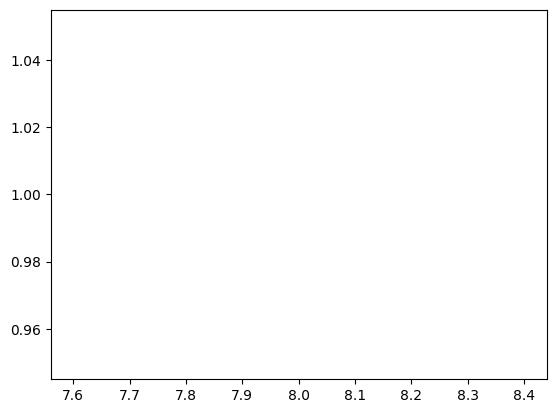

In [378]:
plt.plot(prob[0][:1000])

In [368]:
# x_ = euler_update(jr.PRNGKey(0), x, rc * dt)
x_ = euler_update(jr.PRNGKey(0), x, rp * dt)

[252 252 250 249 252 254 252 253]/256 tokens are valid in the final step


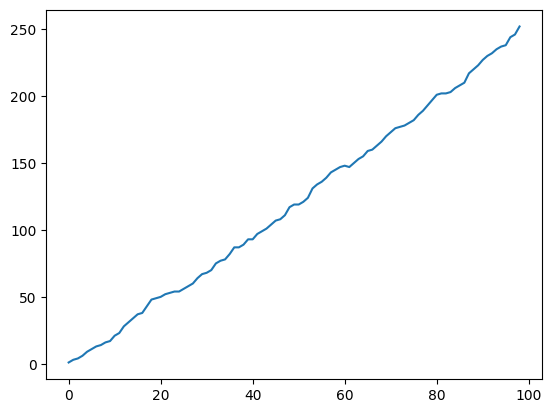

In [390]:
x_hist = hist
mask_curve = jnp.sum(x_hist != 1024, axis=-1)
plt.plot(mask_curve[0])
print(f'{mask_curve[:,-1]}/256 tokens are valid in the final step')

[249 254 255 252 253 253 256 250]/256 tokens are valid in the final step


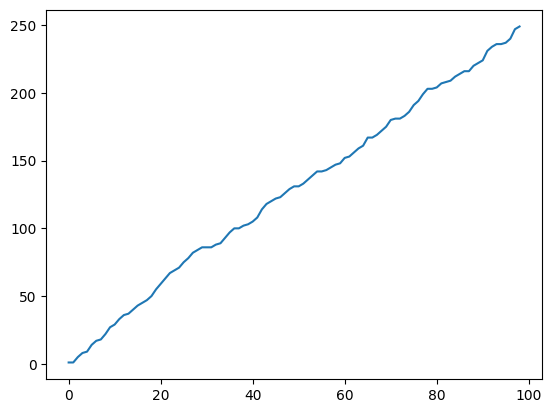

In [266]:
# x_hist = hist["x"]
x_hist = hist
mask_curve = jnp.sum(x_hist != 1024, axis=-1)
plt.plot(mask_curve[0])
print(f'{mask_curve[:,-1]}/256 tokens are valid in the final step')

In [69]:
mask_curve[0]

Array([  3,   7,  13,  17,  23,  29,  33,  34,  39,  40,  49,  58,  65,
        69,  74,  78,  82,  90,  93,  97, 101, 107, 111, 114, 122, 117,
       123, 131, 136, 143, 144, 156, 155, 159, 164, 173, 172, 182, 182,
       189, 194, 194, 194, 205, 215, 215, 226, 232, 237], dtype=int32)

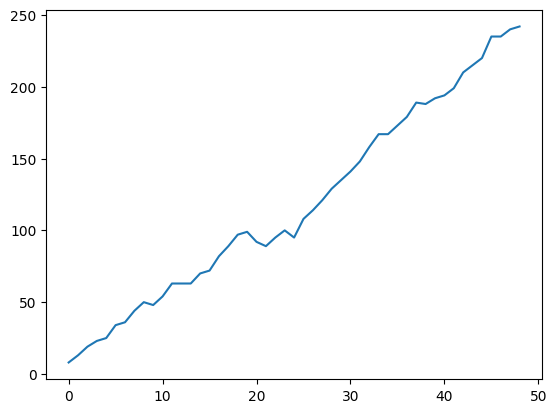

In [41]:
# This is the mask curve of the forward-backward corrector
mask_curve = jnp.sum(tokens_hist != 1024, axis=1)
plt.plot(mask_curve)

## Decode the tokens

In [17]:
from maskgit.nets import vqgan_tokenizer
import tensorflow.compat.v1 as tf
import flax

In [18]:
%cd ~/maskgit-jax

/home/yixiuz/maskgit-jax


In [19]:
tokenizer_model = vqgan_tokenizer.VQVAE(config=config, dtype=jnp.float32, train=False)
tokenizer_path = "maskgit/checkpoints/tokenizer_imagenet256_checkpoint"
with tf.io.gfile.GFile(tokenizer_path, "rb") as f:
    tokenizer_params = flax.serialization.from_bytes(None, f.read())

In [61]:
tokens = jnp.reshape(tokens, [-1, 16, 16])
images = tokenizer_model.apply(tokenizer_params, tokens,
          method=tokenizer_model.decode_from_indices,
          mutable=False)
id = 0

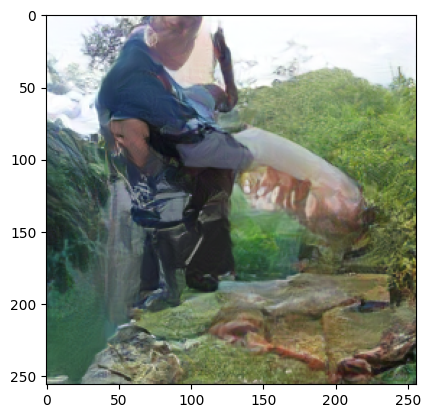

In [73]:
id += 1
id %= 8
plt.imshow(images[id])

# Scratch

In [8]:
def k_gillespies_update(key, x, rates, k=1, cutoff=None):
    eps = 1e-6
    key_exp, key_cat = jr.split(key)
    
    # Get holding times for each dimension
    D = x.shape[0]
    rates = rates.at[jnp.arange(D), x].set(eps)
            
    # Compute total rate (D,)
    rates_sum = jnp.sum(rates, axis=-1)
    # Sample a holding time (D,)
    taus = jr.exponential(key, shape=(D,)) / rates_sum
    # Find which locations each dimension would transition to conditioning on a transition
    jump_target = jr.categorical(key_cat, jnp.log(rates + eps)).astype(jnp.int32)
    
    taus_sorted = jnp.sort(taus, axis=-1)
    # Obtains cut off threshold given the number of updates.
    cutoff = cutoff or taus_sorted[k] # jnp.take_along_axis(taus, k, axis=-1)

    # TODO: add safety that prevents updates if rates_sum is lower than some threshold
    out = jnp.where((taus <= cutoff), jump_target, x)
    return out, cutoff

def backward_process_pc_k_gillespies(apply_fn, params, ts, config, xT, key, forward_process):
    """
    We assume that 1 corrector step is always used after each predictor step 
    """
    # Assuming 1D data
    D = config.data.seq_length
    S = config.model.vocab_size
    corrector = config.sampler.corrector
    k = config.sampler.k
    corrector_entry_time = config.sampler.corrector_entry_time
    corrector_cutoff = config.sampler.corrector_step_cutoff
    
    t = ts[0]
    x = xT

    poisson_jump = poisson_jump_accept
    
    if corrector == "barker":
        corrector_rate = barker_corrector
    elif corrector == "mpf":
        corrector_rate = mpf_corrector
    elif corrector == "forward_backward":
        corrector_rate = forward_backward_corrector
    else:
        raise Exception(f"Unknown corrector: {corrector}")

    def _corrector_entry_cond(state):
        _, x, _, _ = state
        no_corrector = (jnp.sum(x == (S-1)) / D) > corrector_entry_time
        return no_corrector
    
    def _end_cond(state):
        key, x, t, i = state
        not_at_end = t > ts[-1]
        return not_at_end

    def _p_step(state):
        key, x, t, nfe = state
        key, p_key, c_key = jr.split(key, 3)

        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]
        x, dt = k_gillespies_update(p_key, x, rp, k=k)

        t -= dt 
        
        return (key, x, t, nfe+1)
    
    def _pc_step(state):
        key, x, t, nfe = state
        key, p_key, c_key = jr.split(key, 3)

        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rp = res["rates"]
        x, dt = k_gillespies_update(p_key, x, rp, k=k)

        t -= dt 
        
        # Corrector
        res = compute_backward(x, t, apply_fn, params, config, forward_process)
        rc = corrector_rate(res)
        # x = poisson_jump(c_key, x, rc * dt * corrector_step_size)
        x, _ = k_gillespies_update(c_key, x, rc, cutoff=corrector_cutoff)

        return (key, x, t, nfe+2)
        
        # out = {
        #     "x": x,
        #     "rp": rp,
        #     "rc": rc,
        #     "t": t
        # }
        
        # return (x, key), out

    # t_ids = jnp.arange(len(ts)-1)
    # (x, key), out_1 = jax.lax.scan(_p_step, (xT, key), t_ids[:start])
    # (x, _), out_2 = jax.lax.scan(_pc_step, (x, key), t_ids[start:])

    key, x, t, nfe = jax.lax.while_loop(_corrector_entry_cond, _p_step, (key, xT, t, 0))
    _, x, t, nfe = jax.lax.while_loop(_end_cond, _pc_step, (key, x, t, nfe))
    
    x_hist = {
    #     "x": jnp.concatenate([out_1["x"], out_2["x"]]),
    #     "rp": jnp.concatenate([out_1["rp"], out_2["rp"]]),
    #     "rc": out_2["rc"]
        "t": t,
        "nfe": nfe,
        "mask_count": jnp.sum(x == (S-1))
    }

    res = compute_backward(x, ts[-1], apply_fn, params, config, forward_process)
    x0_logits = res["x0_logits"]

    x0_pred = jnp.argmax(x0_logits, axis=1)

    return x0_pred, x_hist